### Imports

In [43]:
import os
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import pickle

### Settings

In [44]:
DIR_DATA = "data"
DIR_TEXTS = os.path.join(DIR_DATA, "texts")
FILE_METADATA = os.path.join(DIR_DATA, "metadata.csv")

### Loading the texts

In [45]:
# Open metadata file
metadata = pd.read_csv(FILE_METADATA)
metadata.head()

,url,title,reading_level,ebook_no,language,release_date,most_recently_updated,downloads,plaintext_url
0,https://books.flotwiskunde.nl/ebooks/84.html,"Frankenstein; Or, The Modern Prometheus",Reading ease score: 65.0 (8th & 9th grade). Ne...,84,English,"Oct 1, 1993","Sep 8, 2025",145303 downloads in the last 30 days.,https://books.flotwiskunde.nl/ebooks/books/84.txt
1,https://books.flotwiskunde.nl/ebooks/2701.html,"Moby Dick; Or, The Whale",Reading ease score: 73.3 (7th grade). Fairly e...,2701,English,"Jul 1, 2001","Sep 11, 2025",115857 downloads in the last 30 days.,https://books.flotwiskunde.nl/ebooks/books/270...
2,https://books.flotwiskunde.nl/ebooks/1342.html,Pride and Prejudice,Reading ease score: 69.2 (8th & 9th grade). Ne...,1342,English,"Jun 1, 1998","Sep 22, 2025",85439 downloads in the last 30 days.,https://books.flotwiskunde.nl/ebooks/books/134...
3,https://books.flotwiskunde.nl/ebooks/1513.html,Romeo and Juliet,Reading ease score: 92.6 (5th grade). Very eas...,1513,English,"Nov 1, 1998","Sep 18, 2025",71504 downloads in the last 30 days.,https://books.flotwiskunde.nl/ebooks/books/151...
4,https://books.flotwiskunde.nl/ebooks/26184.html,Simple Sabotage Field Manual,Reading ease score: 60.5 (8th & 9th grade). Ne...,26184,English,"Aug 4, 2008","Feb 5, 2025",59188 downloads in the last 30 days.,https://books.flotwiskunde.nl/ebooks/books/261...


In [46]:
# Create book list DataFrame and load texts into memory
book_list = pd.DataFrame({
    "id": metadata["ebook_no"].astype(int),
    "reading_ease_score": metadata["reading_level"].astype(str).str.extract(r'Reading ease score: (\d+.\d+)', expand=False),
    "title": metadata["title"],
    "file_size_bytes": pd.Series([os.path.getsize(os.path.join(DIR_TEXTS, f"{ebook_no}.txt")) for ebook_no in metadata["ebook_no"]]).astype(int),
    "text_raw": pd.Series([open(os.path.join(DIR_TEXTS, f"{ebook_no}.txt"), "r", encoding="utf-8").read() for ebook_no in metadata["ebook_no"]]),
}).set_index("id")
book_list.head()

,reading_ease_score,title,file_size_bytes,text_raw
id,,,,
84,65.0,"Frankenstein; Or, The Modern Prometheus",456666,﻿The Project Gutenberg eBook of Frankenstein; ...
2701,73.3,"Moby Dick; Or, The Whale",1298616,"﻿The Project Gutenberg eBook of Moby Dick; Or,..."
1342,69.2,Pride and Prejudice,787340,﻿The Project Gutenberg eBook of Pride and Prej...
1513,92.6,Romeo and Juliet,175193,﻿The Project Gutenberg eBook of Romeo and Juli...
26184,60.5,Simple Sabotage Field Manual,77101,﻿The Project Gutenberg eBook of Simple Sabotag...


### Cleaning the texts

In [47]:
# Retain only the text between the Project Gutenberg header and footer
BOOK_START_REGEX = re.compile(r"\*\*\* START OF THE PROJECT GUTENBERG EBOOK .+ \*\*\*")
BOOK_END_REGEX = re.compile(r"\*\*\* END OF THE PROJECT GUTENBERG EBOOK .+ \*\*\*")
ILLUSTRATION_REGEX = re.compile(r"\[illustration\]", re.IGNORECASE)
REFERENCE_REGEX = re.compile(r"\[\d+\]")
CHAPTER_HEADING_REGEX = re.compile(r"(?im)^\s*chapter\b.*$")
SQUARE_BRACKETS_REGEX = re.compile(r"\[.*?\]")

# Check that all texts contain the header and footer
assert book_list["text_raw"].map(lambda text: bool(BOOK_START_REGEX.search(text))).all(), "Some texts are missing the Project Gutenberg header"
assert book_list["text_raw"].map(lambda text: bool(BOOK_END_REGEX.search(text))).all(), "Some texts are missing the Project Gutenberg footer"

total_illustations_removed = 0
total_references_removed = 0
total_chapter_headings_removed = 0

for text_id in book_list.index:
    
    text: str = book_list.loc[text_id, "text_raw"]
    
    # Find the header and footer using regex, check that they exist
    start_match = BOOK_START_REGEX.search(text)
    end_match = BOOK_END_REGEX.search(text)
    if not start_match or not end_match:
        raise ValueError("Text is missing the Project Gutenberg header or footer")
    
    # Clean header and footer
    text = text[start_match.end():end_match.start()].strip()
    
    # Clean illustrations ([ILLUSTRATION])
    total_illustations_removed += len(ILLUSTRATION_REGEX.findall(text))
    text = ILLUSTRATION_REGEX.sub("", text)
    
    # Clean references ([1], [2], etc.)
    total_references_removed += len(REFERENCE_REGEX.findall(text))
    text = REFERENCE_REGEX.sub("", text)
    
    # Clean other things in square brackets (e.g. [Note: ...], [Footnote: ...], etc.)
    text = SQUARE_BRACKETS_REGEX.sub("", text)
        
    # Chapter headings (lines starting with "Chapter")
    total_chapter_headings_removed += len(CHAPTER_HEADING_REGEX.findall(text))
    text = CHAPTER_HEADING_REGEX.sub("", text)

    # Explicitly mark sentence endings with spaces (or newlines/end of string) so they become their own tokens
    text = re.sub(r'([\.\?!])(?=\s|\n|$)', r' \1 ', text)
    
    # Lowercase everything
    text = text.lower()
    
    book_list.loc[text_id, "text"] = text

print(f"Removed Project Gutenberg headers and footers, {total_illustations_removed} illustrations, {total_references_removed} references, and {total_chapter_headings_removed} chapter headings from the texts.")

KeyboardInterrupt: 

### Examining some statistics about the corpus

Books with the largest vocabularies:


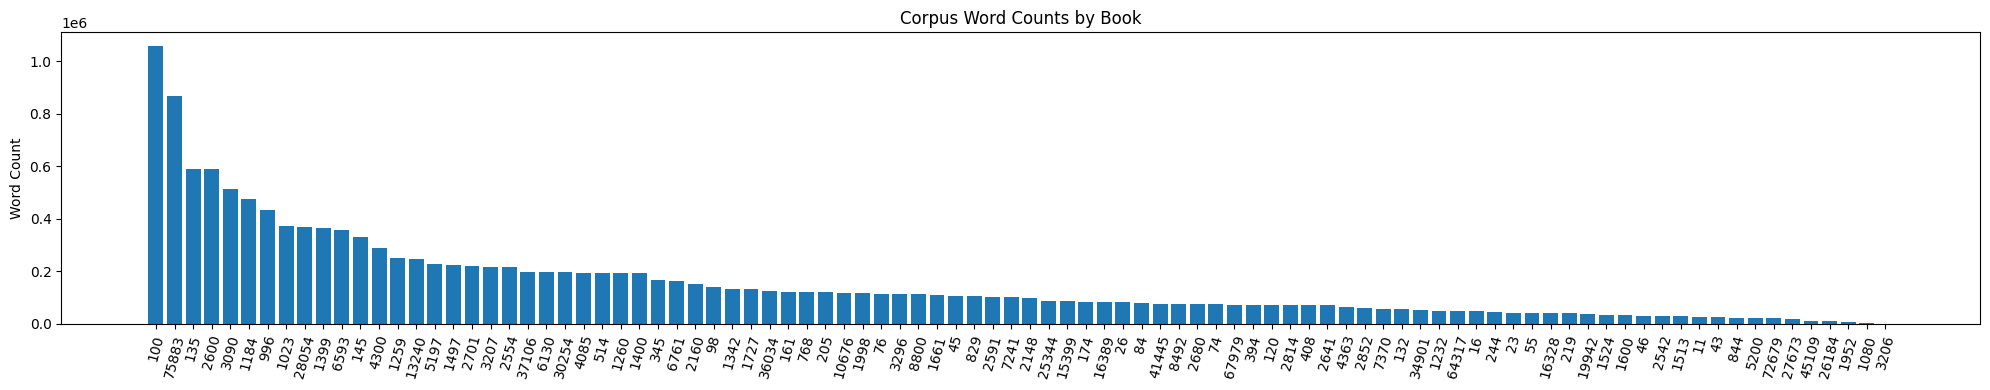

In [ ]:
# Split texts into words and compute some statistics about the corpus
book_list["words"] = book_list["text"].map(lambda text: text.split())
book_list["word_count"] = book_list["words"].map(len)
book_list["vocab_size"] = book_list["words"].map(lambda words: len(set(words)))
book_list["relative_vocab_size"] = book_list["vocab_size"] / book_list["word_count"]
book_list["corpus_word_share"] = book_list["word_count"] / book_list["word_count"].sum()

print(f"Books with the largest vocabularies:")
book_list.sort_values('vocab_size', ascending=False)[['title', 'vocab_size', "word_count", "relative_vocab_size"]].head()

# Plot the distribution of token counts across the corpus
plt.figure(figsize=(20, 4))
book_list_sorted = book_list.sort_values("word_count", ascending=False)
plt.bar(book_list_sorted.index.astype(str), book_list_sorted["word_count"])
plt.xticks(rotation=75)
plt.ylabel("Word Count")
plt.title("Corpus Word Counts by Book")
plt.tight_layout()
plt.show()

In [ ]:
# Compute the frequency of each token across the entire corpus
all_tokens = [token for words in book_list["words"] for token in words]
token_counts = pd.Series(all_tokens).value_counts().rename_axis("token").reset_index(name="count")
print(f"Total unique tokens in the corpus: {token_counts.shape[0]}")
print(f"Most common tokens in the corpus:")
token_counts.head(10)

Total unique tokens in the corpus: 372187
Most common tokens in the corpus:


,token,count
0,the,711444
1,.,630008
2,and,451745
3,of,397267
4,to,362858
5,a,268670
6,in,235871
7,i,195036
8,he,179004
9,that,160122


In [ ]:
singular_tokens = token_counts[token_counts["count"] == 1]
print(f"Number of singular tokens in the corpus: {singular_tokens.shape[0]} ({singular_tokens.shape[0] / token_counts.shape[0]:.2%} of all unique tokens)")
print(f"Sample of singular tokens:")
print(singular_tokens.sample(10))

Number of singular tokens in the corpus: 220716 (59.30% of all unique tokens)
Sample of singular tokens:
                         token  count
312614                álvaro,”      1
245740             isn’t--it’s      1
340105              one—needed      1
352650                   4837,      1
274538  (1803-1849).--dramatic      1
268640                   maws,      1
194938                  lares,      1
319789         arithmeticians,      1
247646                hierius,      1
228560               _bugabu._      1


C:\Users\SJGMC\AppData\Local\Temp\ipykernel_19428\1464752058.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


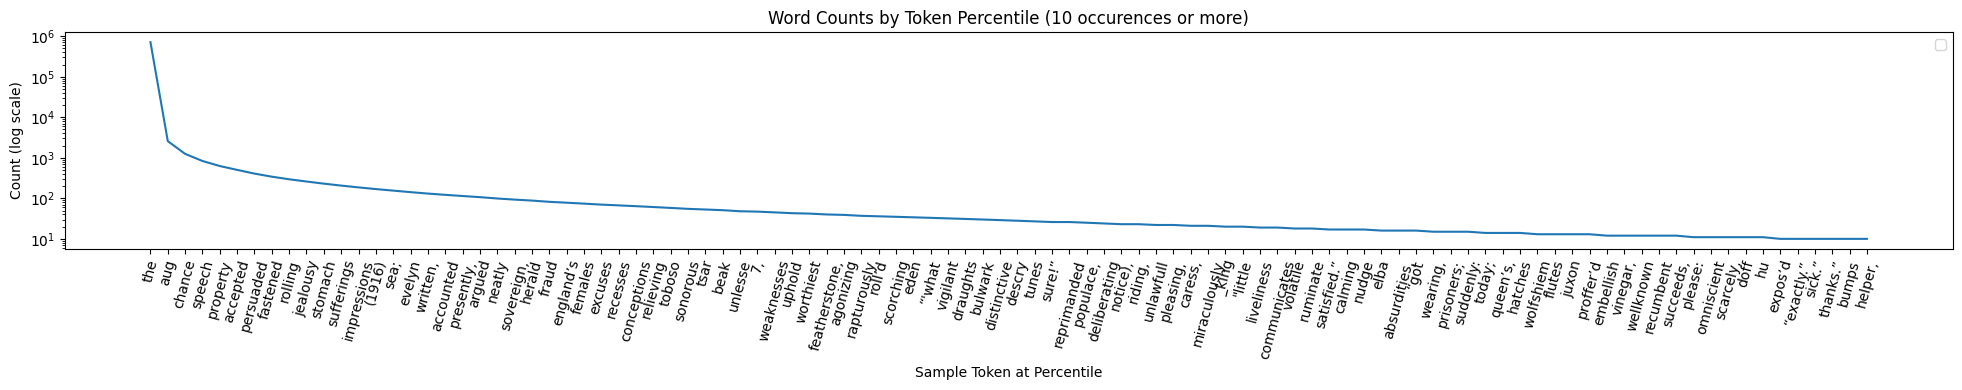

In [ ]:
# Plot the distribution of token counts across the corpus
MIN_OCCURRENCES = 10
token_counts_filtered = token_counts[token_counts["count"] >= MIN_OCCURRENCES]
N_SAMPLES = 100

sample_idxs = np.linspace(0, token_counts_filtered.shape[0] - 1, N_SAMPLES).astype(int)
plt.figure(figsize=(20, 4))
plt.plot(token_counts_filtered["token"].iloc[sample_idxs], token_counts_filtered["count"].iloc[sample_idxs])
plt.xlabel("Sample Token at Percentile")
plt.xticks(rotation=75)
plt.ylabel("Count (log scale)")
plt.title("Word Counts by Token Percentile (10 occurences or more)")
plt.tight_layout()
plt.yscale("log")
plt.legend()
plt.show()

In [ ]:

# Now lets also filter our words so that we filter out numbers and punctuation. 
# We decided on an agressive approach keeping only words that are completely alphabetic, as well as full stops, question marks, and exclamation marks.
filtered_words = [token for token in all_tokens if token.isalpha() or token in {'.', '?', '!'}]
print(f"Total tokens after filtering for alphabetic characters: {len(filtered_words)} ({len(filtered_words) / len(all_tokens):.2%} of all tokens)")

Total tokens after filtering for alphabetic characters: 12352366 (85.58% of all tokens)


In [ ]:
# For performance down the line, we keep only the tokens that occur at least 10 times in the corpus for the rest of the notebook
# Create a set of valid tokens for O(1) lookup
valid_words_set = set(token_counts[token_counts["count"] >= MIN_OCCURRENCES]["token"].values)

# Filter the original corpus list while maintaining order
filtered_words = [token for token in filtered_words if token in valid_words_set]

print(f"Total tokens after filtering for minimum occurrences: {len(filtered_words)} ({len(filtered_words) / len(filtered_words):.2%} of all tokens)")

Total tokens after filtering for minimum occurrences: 12207411 (100.00% of all tokens)


In [ ]:
# Determine the average sentence length in the corpus (in tokens)
sentence_end_tokens = {'.', '?', '!'}
sentences = []
current_sentence = []
for token in filtered_words:
    current_sentence.append(token)
    if token in sentence_end_tokens:
        sentences.append(current_sentence)
        current_sentence = []
        
average_sentence_length = np.mean([len(sentence) for sentence in sentences])
print(f"Average sentence length in the corpus: {average_sentence_length:.2f} words")

Average sentence length in the corpus: 17.15 words


In [ ]:
# Save the cleaned corpus as one text file
with open(os.path.join(DIR_DATA, "cleaned_corpus.txt"), "w", encoding="utf-8") as f:
    f.write(" ".join(filtered_words))
print(f"Cleaned corpus saved to {os.path.join(DIR_DATA, 'cleaned_corpus.txt')}")

Cleaned corpus saved to data\cleaned_corpus.txt


In [ ]:
# Save the cleaned corpus also as a list of indices with a dictionary mapping indices to tokens
token_to_index = {token: idx for idx, token in enumerate(valid_words_set)}
index_to_token = {idx: token for token, idx in token_to_index.items()}

cleaned_corpus_indices_path = os.path.join(DIR_DATA, "cleaned_corpus_indices.pkl")
cleaned_corpus_token_to_index_path = os.path.join(DIR_DATA, "token_to_index.pkl")
cleaned_corpus_index_to_token_path = os.path.join(DIR_DATA, "index_to_token.pkl")

with open(cleaned_corpus_indices_path, "wb") as f:
    pickle.dump([token_to_index[token] for token in filtered_words], f)

with open(cleaned_corpus_token_to_index_path, "wb") as f:
    pickle.dump(token_to_index, f)
        
with open(cleaned_corpus_index_to_token_path, "wb") as f:
    pickle.dump(index_to_token, f)
        
print(f"Cleaned corpus indices saved to {cleaned_corpus_indices_path}")
print(f"Token to index mapping saved to {cleaned_corpus_token_to_index_path}")
print(f"Index to token mapping saved to {cleaned_corpus_index_to_token_path}")

Cleaned corpus indices saved to data\cleaned_corpus_indices.pkl
Token to index mapping saved to data\token_to_index.pkl
Index to token mapping saved to data\index_to_token.pkl
